In [1]:
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os
import json
from sklearn.model_selection import train_test_split
import shutil
import cv2
import math

In [2]:
augmented_df = pd.read_csv("/home/Special_Problem/yolo_dataset_version_2/preprocessed/augmented_preprocessed.csv")

In [3]:
augmented_df.head()

,file,class_id,x_min,y_min,bbox_width,bbox_height,image_path
0,LS-155.jpg,1,160.001632,745.999182,93.998720,76.000284,/home/Special_Problem/yolo_dataset_version_1/i...
1,LS-155.jpg,1,53.999856,669.000342,63.001376,48.999828,/home/Special_Problem/yolo_dataset_version_1/i...
2,LS-155.jpg,1,23.999936,619.999476,70.999296,58.999920,/home/Special_Problem/yolo_dataset_version_1/i...
3,LS-155.jpg,1,208.998928,651.999978,73.000320,73.999020,/home/Special_Problem/yolo_dataset_version_1/i...
4,LS-155.jpg,1,275.000296,672.999756,64.999312,67.000824,/home/Special_Problem/yolo_dataset_version_1/i...


In [4]:
combined_df = (
    augmented_df.groupby(["file", "image_path"])
    .agg({
        "class_id": list,
        "x_min": list,
        "y_min": list,
        "bbox_width": list,
        "bbox_height": list
    })
    .reset_index()
)

In [5]:
def get_normalize_bounding_box(x_min, y_min, bbox_width, bbox_height, img_width, img_height):
    x_center = (x_min + bbox_width / 2) / img_width
    y_center = (y_min + bbox_height / 2) / img_height
    w_norm = bbox_width / img_width
    h_norm = bbox_height / img_height
    return x_center, y_center, w_norm, h_norm

In [6]:
def visualization(bboxes, labels, ax):
    for box, label in zip(bboxes, labels):
        # x_min, y_min, box_width, box_height = map(int, box)
        x_min, y_min, box_width, box_height = box
        if label == 1:
            rect = plt.Rectangle(
            ( x_min, y_min),
                box_width, box_height,
                linewidth=.2, edgecolor="blue", facecolor="none"
            )
        else:
            rect = plt.Rectangle(
            ( x_min, y_min),
                box_width, box_height,
                linewidth=.5, edgecolor="red", facecolor="none"
            )
        ax.add_patch(rect)
        ax.text(
            x_min, y_min - 5, label,
            color="blue", fontsize=2, weight="bold"
        )

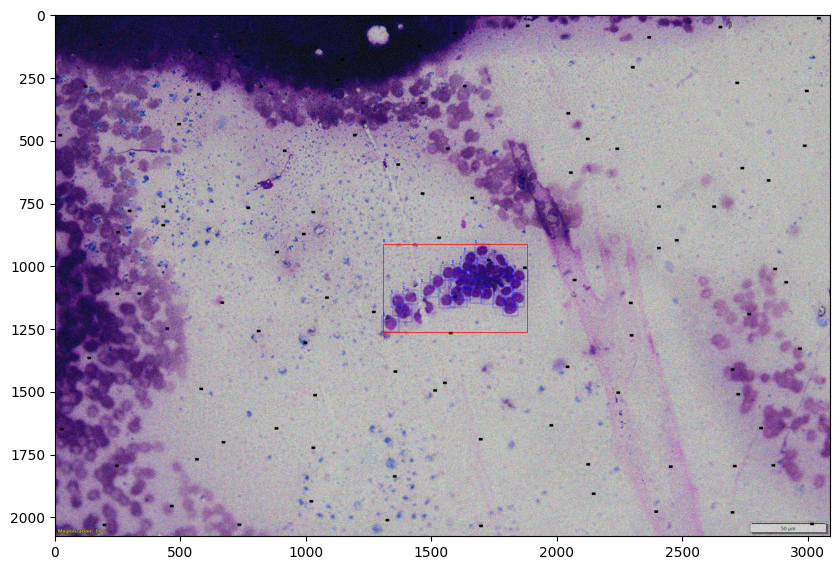

In [7]:
for _, group in combined_df.iterrows():
    bboxes = list(zip(group["x_min"], group["y_min"], group["bbox_width"], group["bbox_height"]))
    labels = group["class_id"]
    augmented_image_path = group["image_path"]
    bgr_image = cv2.imread(augmented_image_path)
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    img_height, img_width, _ =  rgb_image.shape
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(rgb_image)
    visualization(bboxes, labels, ax)
    plt.show()
    break
    

In [8]:
def get_coordinates_intersections(x_min, t_x_min, y_min, t_y_min, x_max, t_x_max, y_max, t_y_max):
    return (
        max(x_min, t_x_min),   # overlap left
        max(y_min, t_y_min),   # overlap top
        min(x_max, t_x_max),   # overlap right
        min(y_max, t_y_max)    # overlap bottom
    )

In [10]:
def get_normalize_bounding_box(x_min, y_min, bbox_width, bbox_height, img_width, img_height):
    x_center = (x_min + bbox_width / 2) / img_width
    y_center = (y_min + bbox_height / 2) / img_height
    w_norm = bbox_width / img_width
    h_norm = bbox_height / img_height
    return x_center, y_center, w_norm, h_norm

In [32]:
# group["class_id"], group["x_min"], group["y_min"], group["bbox_width"], group["bbox_height"]
def save_adjust_bboxes_for_tile(annotations, tile_x, tile_y, tile_size, tile_id, file, tile, min_pixel_size = 8):
    tile_bboxes = []
    tile_labels = []
    has_annotation = False
    label_out_path = f"/home/Special_Problem/yolo_dataset_version_2/labels/train/augmented/{file.split('.')[0] + '_' + tile_id}.txt"
    for annotation in annotations:
        # Original Bounding Box
        x_min, y_min = annotation[1], annotation[2]
        x_max, y_max = x_min + annotation[3], y_min + annotation[4]

        # Tile Corners
        t_x_min, t_y_min = tile_x, tile_y
        t_x_max, t_y_max = t_x_min + tile_size, t_y_min + tile_size

        ix1, iy1, ix2, iy2 = get_coordinates_intersections(
            x_min, t_x_min, y_min, t_y_min, x_max, t_x_max, y_max, t_y_max
        )
        if ix1 < ix2 and iy1 < iy2:
            new_width = ix2 - ix1
            new_height = iy2 - iy1
            if new_width >= min_pixel_size and new_height >= min_pixel_size:
                with open(label_out_path, "a") as out_f:
                    new_x = ix1 - tile_x
                    new_y = iy1 - tile_y
                    # tile_bboxes.append((new_x, new_y, new_width, new_height))
                    # tile_labels.append(annotation[0])
                    has_annotation = True
                    x_center, y_center, w_norm, h_norm = get_normalize_bounding_box(new_x, new_y, new_width, new_height, tile_size, tile_size)
                    out_f.write(f"{annotation[0]} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")
    
    # Save image only if annotation exists
    if has_annotation:
        # fig, ax = plt.subplots(1, figsize=(10, 10))
        # ax.imshow(tile)
        # visualization(tile_bboxes, tile_labels, ax)
        # plt.show()
        format = file.split('.')[-1]
        image_out_path = f"/home/Special_Problem/yolo_dataset_version_2/images/train/augmented/{file.split('.')[0] + '_' + tile_id}.{format}"
        save_dir = f'/home/Special_Problem/yolo_dataset_version_2/augmented_tiles/{file}'
        os.makedirs(save_dir, exist_ok=True)
        cv2.imwrite(f'/home/Special_Problem/yolo_dataset_version_2/augmented_tiles/{file}/{tile_id}.{format}', tile)
        cv2.imwrite(image_out_path, tile)

In [33]:
TILE_SIZE = 512
OVERLAP = 0.25
row = []
for _, group in combined_df.iterrows():
    annotations = list(zip(group["class_id"], group["x_min"], group["y_min"], group["bbox_width"], group["bbox_height"]))
    augmented_image_path = group["image_path"]
    bgr_image = cv2.imread(augmented_image_path)
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    img_height, img_width, _ =  rgb_image.shape
    stride = int(TILE_SIZE * (1 - OVERLAP))
    tile_id = 0
    for row_idx, y0 in enumerate(range(0, img_height, stride)):
        for col_idx, x0 in enumerate(range(0, img_width, stride)):
            tile_id = f"{row_idx}_{col_idx}"
            x1 = min(x0 + TILE_SIZE, img_width)
            y1 = min(y0 + TILE_SIZE, img_height)
            tile = rgb_image[y0:y1, x0:x1]
            save_adjust_bboxes_for_tile(annotations, x0, y0, TILE_SIZE, tile_id, group["file"], tile)